# L3a Advanced: Market-Impact Models

Trading cost is not summarized by one universal “impact” number. Different models answer different questions about order size, order-book events, and time. This notebook begins with the exact cost of walking a displayed book, then develops three reduced-form descriptions: linear signed-volume impact, order-flow imbalance, and transient impact with resilience.

The organizing question is:

> Which price response are we modeling, over what horizon, and relative to which benchmark?

Work through the companion order-book-mechanics notebook first, because the code below uses the same price-time-priority engine.

> __Learning Objectives:__
>
> By the end of this notebook, we will be able to:
>
> * __Mechanical impact:__ Measure what an order costs by walking it through the displayed book and comparing the realized average price against a stated benchmark. Separate the volume-weighted average price, the depth slippage, the midpoint change, and the implementation shortfall, since each answers a different cost question.
> * __Reduced-form models:__ Distinguish impact that follows mechanically from a book snapshot from impact estimated statistically across many orders. Fit coefficients that relate price change to signed volume and to order-flow imbalance, and state the horizon each coefficient describes.
> * __Transient impact:__ Represent impact as a response that decays between trades rather than a permanent level shift. Compare the cost of executing a block against the cost of slicing it, with and without decay, to see what resilience buys.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course environment and loads the `VLQuantitativeFinancePackage` matching engine, along with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/), and the `LinearAlgebra` and `Random` standard libraries. 

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Implementation
Next, we define helper functions that we use throughout the notebook. 

* The `impact_seed_book(...)` function builds a synthetic book with four bid and four ask levels, and the `mechanical_buy(...)` function resets that book, submits a market buy order, and returns a named tuple of execution measurements for that order. We also set shared plot styling defaults.

Let's define these helper functions:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    fg_legend = :transparent,
    linewidth = 2,
);

function impact_seed_book(; depth_scale::Int = 1)
    book = MyOrderBook(tick_size = 0.01)
    orders = [
        MyLimitOrder(1, Buy,  9_999, 100 * depth_scale),
        MyLimitOrder(2, Buy,  9_998, 150 * depth_scale),
        MyLimitOrder(3, Buy,  9_996, 250 * depth_scale),
        MyLimitOrder(4, Buy,  9_993, 300 * depth_scale),
        MyLimitOrder(5, Sell, 10_001,  80 * depth_scale),
        MyLimitOrder(6, Sell, 10_002, 120 * depth_scale),
        MyLimitOrder(7, Sell, 10_004, 200 * depth_scale),
        MyLimitOrder(8, Sell, 10_007, 300 * depth_scale),
    ]
    foreach(order -> submit_order!(book, order), orders)
    return book
end

function mechanical_buy(quantity::Int; depth_scale::Int = 1)
    book = impact_seed_book(; depth_scale = depth_scale)
    midpoint_before = midprice(book)
    best_ask_before = best_quotes(book).ask
    report = submit_order!(book, MyMarketOrder(Buy, quantity))
    @assert report.executed_quantity == quantity
    @assert validate_order_book(book)
    average_price = execution_vwap(report)
    return (
        order_quantity = quantity,
        vwap = average_price,
        depth_slippage_per_share = average_price - best_ask_before,
        implementation_shortfall = implementation_shortfall(report, midpoint_before),
        midpoint_after = midprice(book),
        midpoint_change = midprice(book) - midpoint_before,
        price_levels_consumed = length(unique(fill.price_ticks for fill in report.fills)),
    )
end

mechanical_buy (generic function with 1 method)

___

## Task 1: Measure what an order costs

In this task, we'll define the quantities that describe an execution, then compute them on a book we control completely. Getting the measurements right comes first, because a reported trading cost means nothing until we say which of these quantities it is.

Let $m_0$ and $a_0$ be the midpoint and best ask immediately before a buy order. For an executed quantity $Q$, the useful measurements are given by:

$$
\begin{aligned}
\operatorname{VWAP}(Q) &= \frac{1}{Q}\sum_j p_j f_j,\\
\text{depth slippage per share} &= \operatorname{VWAP}(Q)-a_0,\\
\text{implementation shortfall} &=Q\bigl(\operatorname{VWAP}(Q)-m_0\bigr),\\
\text{midpoint change} &=m_+-m_0.
\end{aligned}
$$

These four are not interchangeable. VWAP averages the execution prices actually received, depth slippage and implementation shortfall turn that average into a cost, and the midpoint change reports how the quotes responded rather than what the order paid. Implementation shortfall differs from the other two costs because it also carries the spread the trade crossed.

Let's walk a range of order sizes through identical copies of one book:

We reset the same book before every order, so size is the only thing that varies. The resulting curve is therefore deterministic: it is a transformation of the displayed ask schedule rather than an empirical law.

In [3]:
order_sizes = [10, 40, 80, 100, 150, 200, 300, 400, 500, 600]
mechanical_results = DataFrame([mechanical_buy(quantity) for quantity in order_sizes])

# Display every execution measurement for each order size.
pretty_table(mechanical_results;
    column_labels = ["Order quantity (shares)", "VWAP (USD)", "Depth slippage (USD/share)",
        "Implementation shortfall (USD)", "Midpoint after (USD)", "Midpoint change (USD)",
        "Price levels consumed"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    fit_table_in_display_vertically = false,
    formatters = [fmt__printf("%.4f", [2, 3, 4, 5, 6])])

========================== ============ ============================ ================================ ====================== ======================= ========================
  Order quantity (shares)   VWAP (USD)   Depth slippage (USD/share)   Implementation shortfall (USD)   Midpoint after (USD)   Midpoint change (USD)   Price levels consumed 
========================== ============ ============================ ================================ ====================== ======================= ========================
                       10     100.0100                       0.0000                           0.1000               100.0000                  0.0000                       1
                       40     100.0100                       0.0000                           0.4000               100.0000                  0.0000                       1
                       80     100.0100                       0.0000                           0.8000               100.0050            

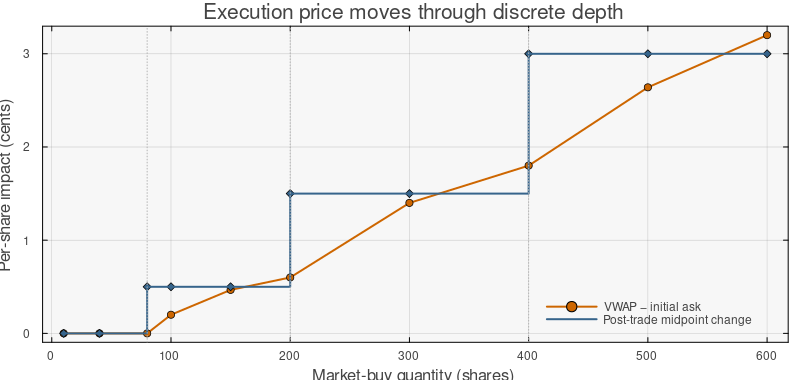

In [4]:
p1 = plot(
    mechanical_results.order_quantity,
    100 .* mechanical_results.depth_slippage_per_share;
    marker = :circle, color = :darkorange3, label = "VWAP − initial ask",
    xlabel = "Market-buy quantity (shares)", ylabel = "Per-share impact (cents)",
    title = "Execution price moves through discrete depth", size = (800, 380),
)
plot!(p1, mechanical_results.order_quantity,
    100 .* mechanical_results.midpoint_change;
    seriestype = :steppost, marker = :diamond, color = :steelblue4,
    label = "Post-trade midpoint change")
for boundary in (80, 200, 400)
    vline!(p1, [boundary]; color = :gray70, linewidth = 1, linestyle = :dot, label = "")
end
p1

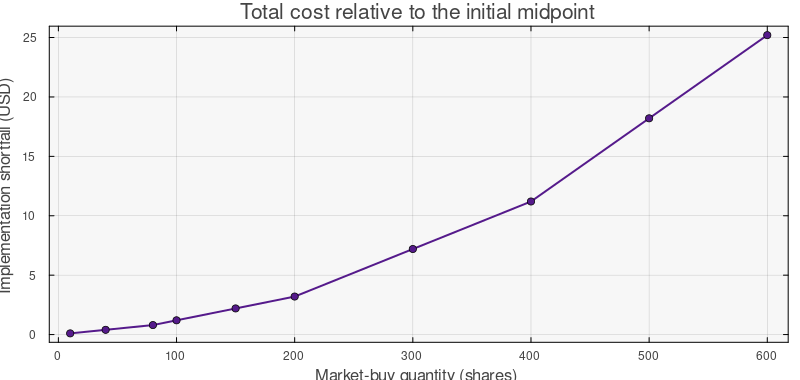

In [5]:
p2 = plot(
    mechanical_results.order_quantity,
    mechanical_results.implementation_shortfall;
    marker = :circle, color = :purple4, label = "",
    xlabel = "Market-buy quantity (shares)", ylabel = "Implementation shortfall (USD)",
    title = "Total cost relative to the initial midpoint", size = (800, 380),
)
p2

The midpoint-change curve is a staircase: it is flat while an order only partially consumes a price level, and it steps up when the order exhausts a level, at the 80-, 200-, and 400-share depth boundaries (the dotted lines in the first figure). The execution-price curve instead rises between those boundaries, because the shares beyond an exhausted level fill at the next, worse price and pull the volume-weighted average up. Implementation shortfall is piecewise linear: its slope is the current marginal price minus the initial midpoint, so it steepens at every depth boundary as larger orders pay worse marginal prices.

This experiment conditions on one displayed snapshot. It omits hidden liquidity, new limit orders, cancellations during execution, information, and strategic response. We should therefore call it __mechanical book-walking impact__, not a universal market-impact function.

### The same order has different impact in a different state

Impact is large relative to the depth available, not simply because the share count is large. To separate those two things, we send the same 300-share order into the baseline book and into a book holding three times the quantity at every price.

In [6]:
state_comparison = DataFrame([
    merge((book_state = "Baseline depth",), mechanical_buy(300; depth_scale = 1)),
    merge((book_state = "Three-times depth",), mechanical_buy(300; depth_scale = 3)),
])
# Display the same order measured against each book state.
pretty_table(select(state_comparison, :book_state, :order_quantity, :vwap,
        :depth_slippage_per_share, :midpoint_change, :implementation_shortfall);
    column_labels = ["Book state", "Order quantity (shares)", "VWAP (USD)",
        "Depth slippage (USD/share)", "Midpoint change (USD)",
        "Implementation shortfall (USD)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.4f", [3, 4, 5, 6])])

==================== ========================= ============ ============================ ======================= =================================
         Book state   Order quantity (shares)   VWAP (USD)   Depth slippage (USD/share)   Midpoint change (USD)   Implementation shortfall (USD) 
==================== ========================= ============ ============================ ======================= =================================
     Baseline depth                       300     100.0240                       0.0140                  0.0150                           7.2000
  Three-times depth                       300     100.0120                       0.0020                  0.0050                           3.6000
==================== ========================= ============ ============================ ======================= =================================


The quantity is identical, but the deeper book absorbs it closer to the initial quote. This is why an impact coefficient must be interpreted together with liquidity and sampling horizon.

___

## Task 2: Fit reduced-form impact models

In this task, we'll leave the exact book behind and estimate two statistical models of price response, one driven by signed volume and one by quote events. We fit both by least squares to simulated data, so we can compare what the estimator recovers against what we put in.

The simplest model links signed order flow to the size and direction of the price move. A common reduced-form benchmark is:

$$
\Delta m_t=\lambda q_t+\varepsilon_t,
$$

where $q_t>0$ denotes buyer-initiated volume, $q_t<0$ denotes seller-initiated volume, and $\lambda$ has units of price change per signed share. In Kyle's equilibrium model, the related slope summarizes price sensitivity to order flow and market depth, whereas here we treat the equation as a statistical benchmark and estimate it by least squares through the origin:

$$
\widehat\lambda=\frac{\sum_t q_t\Delta m_t}{\sum_t q_t^2}.
$$

Reference: Albert S. Kyle, [“Continuous Auctions and Insider Trading”](https://doi.org/10.2307/1913210), *Econometrica* 53(6), 1985.

Let's simulate signed-volume windows and recover the coefficient by least squares:

In [7]:
Random.seed!(5660)
number_of_windows = 400
signed_volume = rand(-500:500, number_of_windows)
lambda_true = 2.5e-5                         # USD per signed share
midpoint_noise = 0.004 .* randn(number_of_windows)
midpoint_change = lambda_true .* signed_volume .+ midpoint_noise
lambda_hat = dot(signed_volume, midpoint_change) / dot(signed_volume, signed_volume)

linear_fit_summary = DataFrame(
    parameter = ["True λ", "Estimated λ"],
    value_USD_per_signed_share = [lambda_true, lambda_hat],
)

# Display the true and the recovered impact coefficient.
pretty_table(linear_fit_summary;
    column_labels = ["Coefficient", "Value (USD per signed share)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.8f", [2])])

============== ===============================
  Coefficient   Value (USD per signed share) 
============== ===============================
       True λ                     0.00002500
  Estimated λ                     0.00002444
============== ===============================


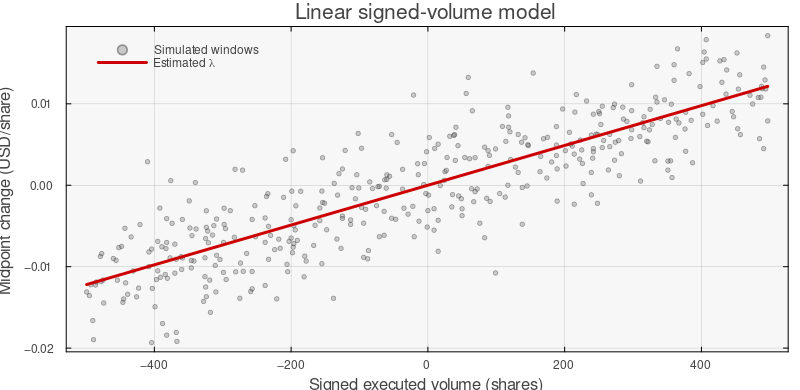

In [8]:
volume_grid = range(extrema(signed_volume)...; length = 200)
scatter(
    signed_volume, midpoint_change;
    markersize = 2.5, markeralpha = 0.35, color = :gray45, label = "Simulated windows",
    xlabel = "Signed executed volume (shares)", ylabel = "Midpoint change (USD/share)",
    title = "Linear signed-volume model", size = (800, 390),
)
plot!(volume_grid, lambda_hat .* volume_grid;
    color = :red3, linewidth = 3, label = "Estimated λ")

The fitted line averages across many event windows. Unlike the staircase produced by a single book snapshot, it is a reduced-form conditional expectation. Its slope depends on how trades are signed, the time interval used to aggregate them, and the liquidity regime represented in the data.

___

### Order-flow imbalance includes non-trade events

Short-horizon prices respond to changes in supply and demand at the quotes, not only to completed trades, so a measure built from executions alone misses part of the pressure. A simple best-quote order-flow-imbalance convention assigns a positive contribution to quantity added at the bid or removed from the ask, and a negative contribution to quantity removed from the bid or added at the ask. Limit orders and cancellations therefore enter the same state-change measure as executions. These contributions use only quantity changes at the standing quote prices, while the full Cont-Kukanov-Stoikov measure also accounts for changes in the quote prices themselves. Summing the signed events $e_n$ over window $k$, and writing $\Delta m_k$ for the midpoint change measured over that same window, gives:

$$
\operatorname{OFI}_k=\sum_{n\in k}e_n,
\qquad
\Delta m_k=\beta\operatorname{OFI}_k+\epsilon_k.
$$

Reference: Rama Cont, Arseniy Kukanov, and Sasha Stoikov, [“The Price Impact of Order Book Events”](https://doi.org/10.1093/jjfinec/nbt003), *Journal of Financial Econometrics* 12(1), 2014.

Let's record a synthetic stream of best-quote events and sign each one by this convention. The `event_type` column records whether a change came from a new limit order, a cancellation, or an execution against the quote, but the signing uses only the book side and the direction of the change. We store the stream in the `events::DataFrame` variable:

In [9]:
function signed_ofi_event(side::String, action::String, quantity::Int)
    if (side == "bid" && action == "add") || (side == "ask" && action == "remove")
        return quantity
    end
    return -quantity
end

events = let
    table = DataFrame(
        window = repeat(1:6, inner = 4),
        book_side = repeat(["bid", "ask", "bid", "ask"], 6),
        action = repeat(["add", "add", "remove", "remove"], 6),
        event_type = repeat(["limit order", "limit order", "cancellation", "cancellation",
                             "limit order", "limit order", "execution", "execution"], 3),
        quantity = [80, 35, 20, 60, 45, 90, 70, 15, 110, 20, 30, 85,
                    30, 75, 95, 25, 70, 45, 10, 100, 40, 105, 55, 35],
    )
    table.ofi_contribution = [
        signed_ofi_event(row.book_side, row.action, row.quantity) for row in eachrow(table)
    ]
    table
end

Row,window,book_side,action,event_type,quantity,ofi_contribution
,Int64,String,String,String,Int64,Int64
1,1,bid,add,limit order,80,80
2,1,ask,add,limit order,35,-35
3,1,bid,remove,cancellation,20,-20
4,1,ask,remove,cancellation,60,60
5,2,bid,add,limit order,45,45
6,2,ask,add,limit order,90,-90
7,2,bid,remove,execution,70,-70
8,2,ask,remove,execution,15,15
9,3,bid,add,limit order,110,110


So what does the event stream imply for prices? We aggregate the signed contributions within each window and attach a simulated midpoint change, storing the result in the `ofi_windows::DataFrame` variable:

In [10]:
beta_true = 4.0e-5; # USD per share of imbalance
ofi_windows = let
    windows = combine(groupby(events, :window; sort = true), :ofi_contribution => sum => :ofi)
    windows.midpoint_change = beta_true .* windows.ofi .+
        [0.0005, -0.0003, 0.0002, -0.0004, 0.0001, -0.0002]
    windows
end

Row,window,ofi,midpoint_change
,Int64,Int64,Float64
1,1,85,0.0039
2,2,-100,-0.0043
3,3,145,0.006
4,4,-115,-0.005
5,5,115,0.0047
6,6,-85,-0.0036


Finally, we estimate the imbalance coefficient by least squares through the origin. Do we recover a value close to the coefficient used to generate the data?

In [11]:
beta_hat = dot(ofi_windows.ofi, ofi_windows.midpoint_change) /
    dot(ofi_windows.ofi, ofi_windows.ofi)

4.244699339589851e-5

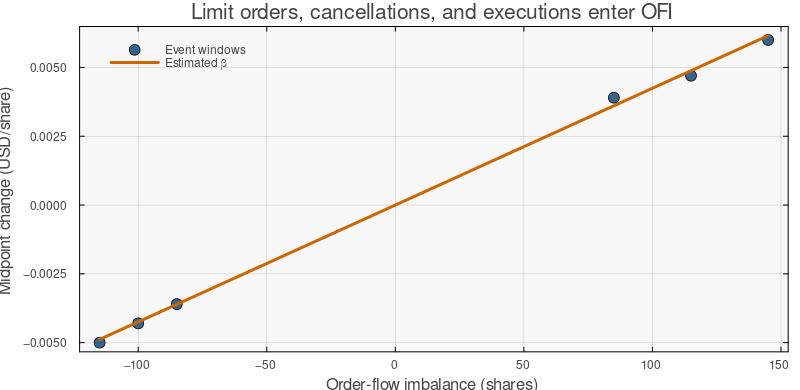

In [12]:
ofi_grid = range(extrema(ofi_windows.ofi)...; length = 100)
scatter(
    ofi_windows.ofi, ofi_windows.midpoint_change;
    marker = :circle, markersize = 6, color = :steelblue4, label = "Event windows",
    xlabel = "Order-flow imbalance (shares)", ylabel = "Midpoint change (USD/share)",
    title = "Limit orders, cancellations, and executions enter OFI", size = (800, 390),
)
plot!(ofi_grid, beta_hat .* ofi_grid;
    color = :darkorange3, linewidth = 3, label = "Estimated β")

OFI is closer to the book's event mechanics than trade volume alone. An ask cancellation and an aggressive buy both remove displayed ask quantity, so both contribute positive pressure under this convention. The model remains an empirical window-level relationship, not a claim that every event causes the fitted price change in isolation.

___

## Task 3: Model impact that decays between trades

In this task, we'll run one block order and a five-slice schedule through an impact model whose effect decays between trades. Splitting an order only helps if the book refills, so the fraction $\rho$ that survives between trades decides which schedule costs less.

A static book cannot describe what happens while an order is spread over time. We therefore introduce an impact state $x_k$ and a trading quantity $u_k$, which evolve as:

$$
x_{k+1}=\rho\bigl(x_k+\eta u_k\bigr),
\qquad 0\leq\rho\leq1.
$$

The trade moves impact from $x_k$ to $x_k+\eta u_k$, so the average execution impact during that trade is $x_k+\tfrac12\eta u_k$, and only the fraction $\rho$ survives until the next decision. Small $\rho$ represents fast resilience, while $\rho=1$ represents no decay at all. This abstraction follows the central point of Obizhaeva and Wang, that execution depends on dynamic liquidity replenishment rather than on static spread and depth alone. See [“Optimal Trading Strategy and Supply/Demand Dynamics”](https://doi.org/10.1016/j.finmar.2012.09.001), *Journal of Financial Markets* 16(1), 2013.

Let's trace a block schedule and a five-slice schedule through this recursion:

In [13]:
function transient_execution(schedule::Vector{Int}; rho::Float64, eta::Float64)
    impact_before = 0.0
    rows = NamedTuple[]
    total_cost = 0.0
    for (step, quantity) in enumerate(schedule)
        average_execution_impact = impact_before + 0.5 * eta * quantity
        total_cost += quantity * average_execution_impact
        impact_after_trade = impact_before + eta * quantity
        impact_after_decay = rho * impact_after_trade
        push!(rows, (
            step = step,
            quantity = quantity,
            impact_before = impact_before,
            average_execution_impact = average_execution_impact,
            impact_after_trade = impact_after_trade,
            impact_after_decay = impact_after_decay,
        ))
        impact_before = impact_after_decay
    end
    return (path = DataFrame(rows), total_cost = total_cost)
end

total_quantity = 450
block_schedule = [450, 0, 0, 0, 0]
sliced_schedule = fill(90, 5)
@assert sum(block_schedule) == total_quantity
@assert sum(sliced_schedule) == total_quantity
eta = 5.0e-5

no_decay_block = transient_execution(block_schedule; rho = 1.0, eta = eta)
no_decay_sliced = transient_execution(sliced_schedule; rho = 1.0, eta = eta)
resilient_block = transient_execution(block_schedule; rho = 0.55, eta = eta)
resilient_sliced = transient_execution(sliced_schedule; rho = 0.55, eta = eta)

cost_comparison = DataFrame(
    liquidity_dynamics = ["No decay", "No decay", "Resilient", "Resilient"],
    schedule = ["Block", "Five slices", "Block", "Five slices"],
    total_quantity = fill(total_quantity, 4),
    impact_cost = [no_decay_block.total_cost, no_decay_sliced.total_cost,
        resilient_block.total_cost, resilient_sliced.total_cost],
)

# Display the modeled impact cost for each schedule and resilience setting.
pretty_table(cost_comparison;
    column_labels = ["Liquidity dynamics", "Schedule", "Total quantity (shares)",
        "Impact cost (USD)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.4f", [4])])

===================== ============= ========================= ====================
  Liquidity dynamics      Schedule   Total quantity (shares)   Impact cost (USD) 
===================== ============= ========================= ====================
            No decay         Block                       450              5.0625
            No decay   Five slices                       450              5.0625
           Resilient         Block                       450              5.0625
           Resilient   Five slices                       450              2.4429
===================== ============= ========================= ====================


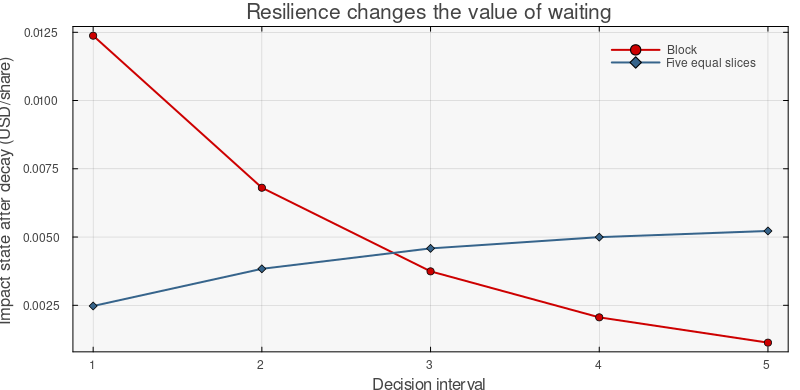

In [14]:
plot(
    resilient_block.path.step, resilient_block.path.impact_after_decay;
    marker = :circle, color = :red3, label = "Block",
    xlabel = "Decision interval", ylabel = "Impact state after decay (USD/share)",
    title = "Resilience changes the value of waiting", size = (800, 390),
    xticks = 1:5,
)
plot!(resilient_sliced.path.step, resilient_sliced.path.impact_after_decay;
    marker = :diamond, color = :steelblue4, label = "Five equal slices")

When $\rho=1$, splitting does not reduce total mechanical impact cost: the later slices inherit all impact created by the earlier ones. When $\rho<1$, impact partially decays between slices, so waiting can reduce modeled cost.

This is not yet an optimal-execution result. Waiting also exposes the unexecuted position to price risk, and a complete optimization must specify that risk, the deadline, and the admissible schedules. The current experiment isolates the role of resilience.

___

## Model map

| Description | Input | Output | Appropriate interpretation |
|:--|:--|:--|:--|
| Displayed-book walk | One book snapshot and order size | VWAP, depth slippage, midpoint change, shortfall | Immediate mechanical execution cost |
| Linear signed volume | Signed executed volume over a window | Conditional midpoint change | Reduced-form average price sensitivity |
| Order-flow imbalance | Limit additions, cancellations, and executions | Short-window midpoint change | Net pressure at the quoted book |
| Transient impact | Trade schedule and resilience parameters | Impact path and schedule cost | Dynamic cost when liquidity recovers |

The models are complementary rather than interchangeable. A book walk is exact conditional on its snapshot but silent about recovery. A regression describes average data behavior but suppresses queue detail. A transient model supplies dynamics but requires assumptions about resilience.

___

## Summary

Market impact is a family of measurements and models whose meaning depends on the book state, event aggregation, and time horizon.

> __Key Takeaways:__
>
> * __Mechanical impact is state dependent:__ Walking orders of increasing size against the same book traces a discrete depth curve rather than a smooth cost function. Changing the depth of that book changes the cost of the identical order, so an impact number means little without the state it was measured in.
> * __Order flow is broader than trade volume:__ Limit-order submissions and cancellations change supply and demand without producing a trade. A short-horizon imbalance measure that counts only executed volume therefore misses part of the pressure that moves the price.
> * __Slicing requires resilience to help:__ In a transient-impact model with no decay, splitting an order into pieces costs the same as executing it at once. The benefit of slicing appears only when impact decays or liquidity replenishes between the child orders.

A credible execution study must therefore name its benchmark, horizon, event convention, and liquidity dynamics before interpreting an impact coefficient.

___